In [1]:
# Filtering IOs code by Clement Ubelmann
## adapted to python function by Laura Gómez Navarro

import numpy
import matplotlib.pylab as plt
from datetime import datetime, timedelta
from netCDF4 import Dataset


# Trying for CARTHE 010 --> as error rises on plot!

In [8]:
filedir = "/Users/Gomez023/src/git/FaSt-SWOT/data/drifters/L1_IMEDEA/"
infile = filedir + 'drifter_carthe015-ime_carthe010.nc'
     

In [9]:
with Dataset(infile, 'r') as fcid:
    time = numpy.array(fcid.variables['time'][1:-1])*60 # seconds (originally in minutes)
    u = numpy.array(fcid.variables['U'][1:-1])
    v = numpy.array(fcid.variables['V'][1:-1])
    lat = numpy.array(fcid.variables['LAT'][1:-1])
    lon = numpy.array(fcid.variables['LON'][1:-1]) # added for plot below
## why ignoring first and last point?


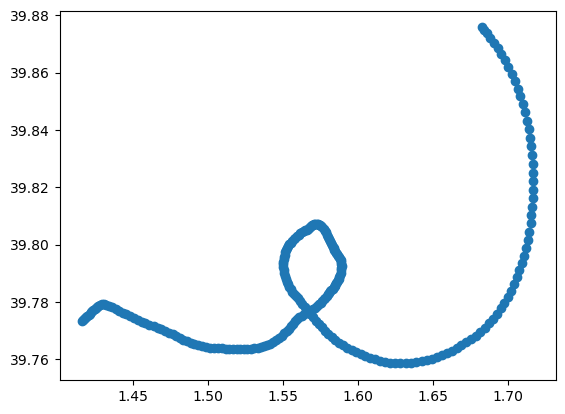

In [10]:
plt.scatter(lon, lat)
plt.show()

In [11]:
u.shape

(264,)

In [12]:
(264 * 10) / 60. # to get hours of drifter traj.

44.0

In [9]:
24*3

72

# --> maybe ALSO problem is drifter is less than 3 days long?!

In [5]:
# Get real and imaginary part:
U = u + 1j*v
U

array([ 0.06742922+0.00792919j,  0.10267772+0.00348886j,
        0.126618  -0.01064467j,  0.14006131-0.03095614j,
        0.14682146-0.04901868j,  0.14923356-0.06205732j,
        0.14815375-0.07065518j,  0.14466335-0.07545091j,
        0.13854631-0.07987214j,  0.13020259-0.0860193j ,
        0.1202292 -0.09449146j,  0.11034257-0.10492486j,
        0.10148891-0.11636447j,  0.09516463-0.12802241j,
        0.09196831-0.14031484j,  0.09186495-0.15230131j,
        0.0951166 -0.16361454j,  0.10037174-0.17388088j,
        0.10625011-0.18317474j,  0.1110381 -0.1912617j ,
        0.11507124-0.19911214j,  0.11758962-0.2071235j ,
        0.11914489-0.21534206j,  0.1195857 -0.22372775j,
        0.11829848-0.23232303j,  0.11510166-0.24165356j,
        0.10953954-0.25071241j,  0.10131654-0.26209446j,
        0.09019441-0.2748038j ,  0.07642413-0.28984092j,
        0.05972286-0.30884663j,  0.04180224-0.33177577j,
        0.02324599-0.35664514j,  0.00547829-0.3807278j ,
       -0.01053091-0.40141177j,

In [6]:
dt = time[1] - time[0]
dt # in seconds, for CARTHE time sampling is 10 mins

600

$fc = 2 * 2 * \frac{\pi}{86164} * sin(mean(lat) * \frac{\pi}{180})$

In [7]:
fc = 2 * 2 * numpy.pi/86164 * numpy.sin(lat.mean() * numpy.pi/180)  # s-1
# earth's rotational period is 86164 s
fc

9.325296206798465e-05

In [8]:
time_conv = numpy.arange(-3*86400, 3*86400+dt, dt)
time_conv

array([-259200, -258600, -258000, -257400, -256800, -256200, -255600,
       -255000, -254400, -253800, -253200, -252600, -252000, -251400,
       -250800, -250200, -249600, -249000, -248400, -247800, -247200,
       -246600, -246000, -245400, -244800, -244200, -243600, -243000,
       -242400, -241800, -241200, -240600, -240000, -239400, -238800,
       -238200, -237600, -237000, -236400, -235800, -235200, -234600,
       -234000, -233400, -232800, -232200, -231600, -231000, -230400,
       -229800, -229200, -228600, -228000, -227400, -226800, -226200,
       -225600, -225000, -224400, -223800, -223200, -222600, -222000,
       -221400, -220800, -220200, -219600, -219000, -218400, -217800,
       -217200, -216600, -216000, -215400, -214800, -214200, -213600,
       -213000, -212400, -211800, -211200, -210600, -210000, -209400,
       -208800, -208200, -207600, -207000, -206400, -205800, -205200,
       -204600, -204000, -203400, -202800, -202200, -201600, -201000,
       -200400, -199

# --> why 3?

In [9]:
len(time_conv)

865

In [10]:
u.shape

(275,)

In [11]:
len(time)

275

$taul = 3 * fc^{-1}$

In [12]:
taul = 3 * fc**-1
taul

32170.559877903885

$gl = exp(-1j * fc * time\_conv) * exp(-taul^{-2} * (time\_conv)^2)$ 

numpy.exp..

$((\frac{gl^T}{\sum{d}})^T)^T$

In [13]:



# gl = 
# (numpy.exp(-1j*numpy.outer(fc[:],time_conv))*numpy.exp(-numpy.outer(taul**-2,time_conv**2))).reshape(len(time),len(time_conv))
gl = numpy.exp(-1j * fc * time_conv) * numpy.exp(-taul**-2 * time_conv**2)
gl = (gl.T / numpy.sum(numpy.abs(gl), axis=0).T).T

Unio = numpy.convolve(U, gl, 'same')

u_nio = numpy.real(Unio)
v_nio = numpy.imag(Unio)


In [16]:
u_nio.shape

(865,)

ValueError: x and y must have same first dimension, but have shapes (275,) and (865,)

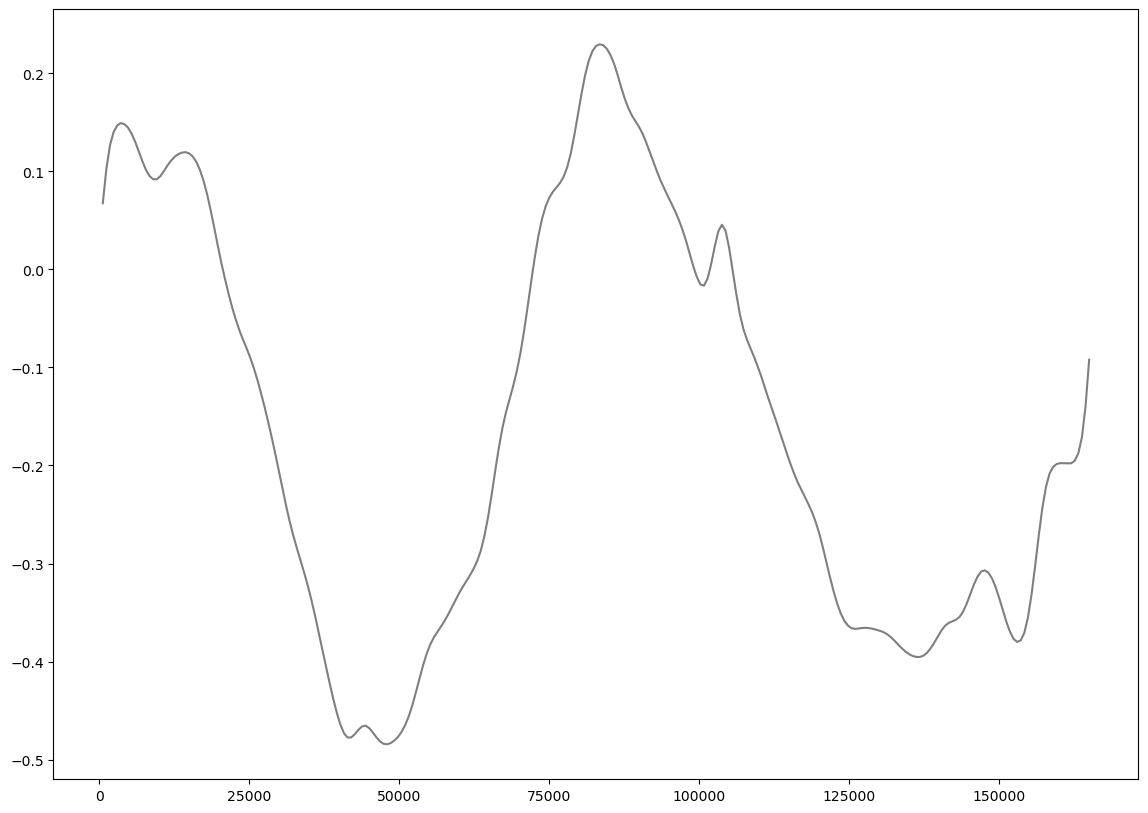

In [14]:
plt.figure(figsize=(14,10))
plt.plot(time, u, c='k', label='u total', alpha=0.5)
plt.plot(time, u_nio, c='r', label='u nio', alpha=0.5)
plt.plot(time, u - u_nio, c='b', label='u res', alpha=0.5)
plt.legend()
plt.grid()
plt.show()
# plt.savefig('drifter_laura.png')


In [30]:
len(u)

1898

In [31]:
len(time)

1898

In [32]:
len(u_nio)

1898